# Demo 1: Data extraction, cleaning, preprocessing and quality assessment

This notebook walks through the data pipeline for the first planner-comparison experiment
(`mini_68`: 68 nuPlan mini scenarios, each simulated with IDM and PDM-Closed).

| Stage | Code | Output |
| --- | --- | --- |
| 1. Extraction | EDA notebook, Docker runners, `tools/build_planner_outcomes.py`, `extract()` | committed manifest + 136-row outcome table |
| 2. Cleaning | `tools/build_paired_dataset.py` `clean()` | typed, deduplicated rows; cleaning log |
| 3. Preprocessing | `preprocess()` | 68-row matched-pair table, model-feature table, log-grouped folds |
| 4. Quality assessment | `assess_quality()`, `tools/validate_scenario_subset.py` | quality report (JSON + Markdown) |

Everything below runs from committed files: **no nuPlan download or Docker is needed**.
The same pipeline from the command line:

```bash
python3 -m tools.build_paired_dataset --overwrite
python3 tools/validate_scenario_subset.py
```

Rules for every field (source, dtype, availability before simulation, model-feature flag,
missing-data policy) live in
[`configs/features/first_experiment_schema.yaml`](../configs/features/first_experiment_schema.yaml);
the design is documented in
[`docs/research/nuplan_scenario_subset_and_required_fields.md`](../docs/research/nuplan_scenario_subset_and_required_fields.md).

In [1]:
from pathlib import Path
import sys

import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tools" / "build_paired_dataset.py").is_file())
sys.path.insert(0, str(ROOT))

from tools.build_paired_dataset import (KEYS, PREFIX, PLANNERS, assess_quality, clean, extract, outcome_metrics,
                                        preprocess, reconstruct_score, render_markdown, write_outputs)
from tools.validate_scenario_subset import DEFAULT_SCHEMA, load_schema, schema_fields, validate

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
COLORS = {"idm": "#1f77b4", "pdm-closed": "#d62728"}
OUTCOME_COLORS = {"pdm_better": "#d62728", "idm_better": "#1f77b4", "tie": "#7f7f7f"}
STATUS_COLORS = {"PASS": "#2ca02c", "WARN": "#ff7f0e", "FAIL": "#d62728", "INFO": "#9ecae1", "SKIP": "#bdbdbd"}
FIG_DIR = ROOT / "artifacts" / "eda" / "demo1"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    """Also keep each figure as a PNG for slides (artifacts/ is ignored by Git)."""
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

schema = load_schema(DEFAULT_SCHEMA)
print("schema:", DEFAULT_SCHEMA.relative_to(ROOT), "| fields:", len(schema_fields(schema)))

schema: configs/features/first_experiment_schema.yaml | fields: 54


## 1. Data extraction

How the committed data was extracted from nuPlan (steps a-c need the nuPlan mini databases
and Docker; they were run once and their outputs are committed):

1. **Scenario catalog** - the [EDA notebook](nuplan_mini_eda.ipynb) scans the 64 nuPlan v1.1
   mini SQLite logs (334,753 tagged anchors, 57,992 benchmark candidates).
2. **Scenario selection** - 5 scenarios per challenge category, seeded and non-overlapping
   -> `configs/scenarios/idm_mini_sample.csv` (68 scenarios, 14 categories, 38 logs, 4 maps).
3. **Simulation** - the Docker runners simulate both planners on the same 68 scenarios
   (nuPlan 1.2.2, closed-loop reactive agents, seed 0).
4. **Outcome extraction** - `tools/build_planner_outcomes.py` reads nuPlan's runner reports
   and metric files -> `artifacts/mini_68/planner_outcomes.{parquet,csv}` (136 rows).

`extract()` loads those committed sources and records their size and SHA-256:

In [2]:
sources = extract(schema)
pd.DataFrame(sources["sources"]).T

,sha256,bytes
configs/scenarios/idm_mini_sample.csv,9162d8ae9d81a1068ca40a1d925a363b16a26e8df9026be84c7726c89e5bfcb5,24857
artifacts/mini_68/planner_outcomes.csv,94bc926f8f176437eef8bd3a8a940289e69e9c938c953eb898c60e0ee355e53c,62005
artifacts/mini_68/experiment.json,cb1a66748f7bd496a245404f8b4b6712e2765be7604a218d9f5ccc8d958b8c55,1281


**Lineage at a glance.** The first three counts come from the EDA notebook's scan of the
mini databases (documented in `configs/scenarios/README.md`); the last two are counted
from the committed files.

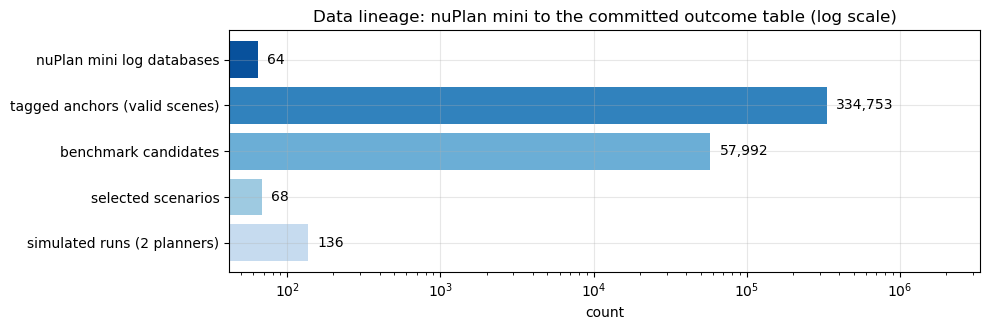

In [3]:
lineage = pd.Series({
    "nuPlan mini log databases": 64,
    "tagged anchors (valid scenes)": 334_753,
    "benchmark candidates": 57_992,
    "selected scenarios": len(sources["manifest_rows"]),
    "simulated runs (2 planners)": len(sources["outcome_rows"]),
})
fig, ax = plt.subplots(figsize=(10, 3.4))
bars = ax.barh(lineage.index[::-1], lineage.values[::-1],
               color=["#08519c", "#3182bd", "#6baed6", "#9ecae1", "#c6dbef"][::-1])
for bar, value in zip(bars, lineage.values[::-1]):
    ax.text(value * 1.15, bar.get_y() + bar.get_height() / 2, f"{value:,}", va="center")
ax.set_xscale("log")
ax.set_xlim(right=lineage.max() * 10)
ax.set(title="Data lineage: nuPlan mini to the committed outcome table (log scale)", xlabel="count")
fig.tight_layout()
save(fig, "01_lineage")
plt.show()

In [4]:
print(f"manifest: {len(sources['manifest_rows'])} scenarios x {len(sources['manifest_columns'])} columns")
pd.DataFrame(sources["manifest_rows"]).head(3)

manifest: 68 scenarios x 11 columns


,scenario_id,log_name,db_file,scenario_token,anchor_timestamp_us,scenario_type,all_scenario_tags,map_name,time_block_id,window_start_us,window_end_us
0,2021.06.09.14.58.55_veh-35_01095_01484:13b93b0c326b5345,2021.06.09.14.58.55_veh-35_01095_01484,2021.06.09.14.58.55_veh-35_01095_01484.db,13b93b0c326b5345,1623266548399842,behind_long_vehicle,behind_long_vehicle|near_long_vehicle|stationary,us-nv-las-vegas-strip,2021.06.09.14.58.55_veh-35_01095_01484:00006,1623266545399842,1623266560399842
1,2021.06.09.14.58.55_veh-35_01894_02311:eb39050f288f5914,2021.06.09.14.58.55_veh-35_01894_02311,2021.06.09.14.58.55_veh-35_01894_02311.db,eb39050f288f5914,1623267374099956,behind_long_vehicle,behind_long_vehicle|near_long_vehicle|on_intersection|traversing_intersection,us-nv-las-vegas-strip,2021.06.09.14.58.55_veh-35_01894_02311:00007,1623267371099956,1623267386099956
2,2021.06.28.15.02.02_veh-38_02398_02848:d515719a27ec512d,2021.06.28.15.02.02_veh-38_02398_02848,2021.06.28.15.02.02_veh-38_02398_02848.db,d515719a27ec512d,1624895101299922,behind_long_vehicle,behind_long_vehicle|near_long_vehicle|stationary,us-nv-las-vegas-strip,2021.06.28.15.02.02_veh-38_02398_02848:00003,1624895098299922,1624895113299922


**What the extracted subset covers:** categories, cities and how many scenarios share a log.

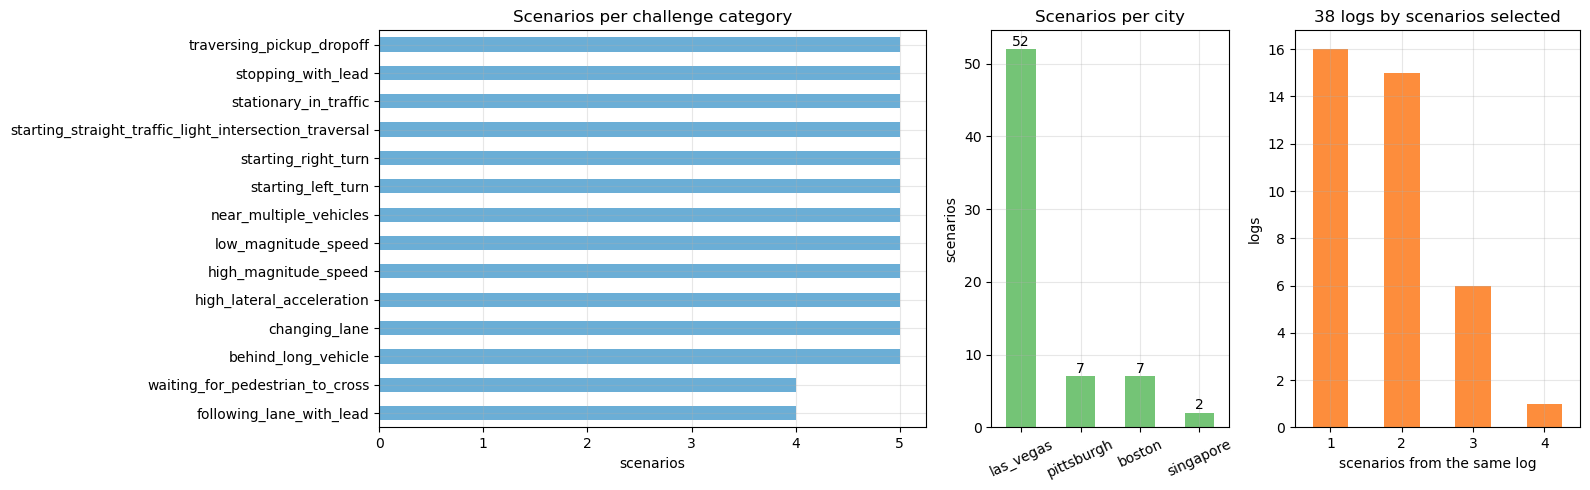

In [5]:
manifest_df = pd.DataFrame(sources["manifest_rows"])
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [2.3, 1, 1.2]})
manifest_df["scenario_type"].value_counts().sort_values().plot.barh(ax=axes[0], color="#6baed6")
axes[0].set(title="Scenarios per challenge category", xlabel="scenarios", ylabel="")
cities = manifest_df["map_name"].map(schema["city_by_map_name"]).value_counts()
cities.plot.bar(ax=axes[1], color="#74c476", rot=25)
axes[1].set(title="Scenarios per city", xlabel="", ylabel="scenarios")
for i, value in enumerate(cities):
    axes[1].text(i, value + 0.5, str(value), ha="center")
per_log = manifest_df.groupby("log_name").size().value_counts().sort_index()
per_log.plot.bar(ax=axes[2], color="#fd8d3c", rot=0)
axes[2].set(title=f"{manifest_df.log_name.nunique()} logs by scenarios selected", xlabel="scenarios from the same log",
            ylabel="logs")
fig.tight_layout()
save(fig, "02_subset_composition")
plt.show()

In [6]:
print(f"outcomes: {len(sources['outcome_rows'])} rows x {len(sources['outcome_columns'])} columns (long format: one row per scenario and planner)")
pd.DataFrame(sources["outcome_rows"])[["scenario_id", "planner", "scenario_type", "score", "succeeded", "run_id"]].head(4)

outcomes: 136 rows x 24 columns (long format: one row per scenario and planner)


,scenario_id,planner,scenario_type,score,succeeded,run_id
0,2021.05.12.22.00.38_veh-35_01008_01518:54f95d530b535ebf,idm,low_magnitude_speed,0.9954366494094804,True,idm_mini_20261001T021827737561Z
1,2021.05.12.22.00.38_veh-35_01008_01518:54f95d530b535ebf,pdm-closed,low_magnitude_speed,1.0,True,pdm-closed_mini_20261001T021818248545Z
2,2021.05.12.22.00.38_veh-35_01008_01518:bc45cfff686751c4,idm,high_magnitude_speed,1.0,True,idm_mini_20261001T021827737561Z
3,2021.05.12.22.00.38_veh-35_01008_01518:bc45cfff686751c4,pdm-closed,high_magnitude_speed,1.0,True,pdm-closed_mini_20261001T021818248545Z


The simulation step is reproducible: the runner rebuilds the exact nuPlan command from the
manifest (shown here without running it; the token and log lists are abbreviated).

In [7]:
from tools.idm_mini_reproducer import DEFAULT_SAMPLE, load_scenarios
from tools.pdm_mini_reproducer import build_command

scenarios = load_scenarios(DEFAULT_SAMPLE)
command = build_command(scenarios, Path("/opt/nuplan-devkit"), "python", Path("/artifacts/mini_68/pdm_closed"), "demo")
for arg in command[2:]:
    print("  ", arg if len(arg) < 110 else arg[:105] + " ...")

   +simulation=closed_loop_reactive_agents
   planner=pdm_closed_planner
   scenario_builder=nuplan_mini
   scenario_filter=nuplan_challenge_scenarios
   scenario_filter.scenario_tokens=["13b93b0c326b5345","eb39050f288f5914","d515719a27ec512d","77e404c84d6b5d ...
   scenario_filter.log_names=["2021.05.12.22.00.38_veh-35_01008_01518","2021.05.12.22.28.35_veh-35_00620_011 ...
   scenario_filter.remove_invalid_goals=true
   worker=sequential
   seed=0
   experiment_name=planner_comparison
   experiment_uid=demo
   group=/artifacts/mini_68/pdm_closed
   log_config=true
   verbose=true
   hydra.searchpath=[pkg://nuplan.planning.script.config.common,pkg://nuplan.planning.script.experiments,pkg ...


**Not extracted yet:** pre-simulation scenario features (ego speed, nearby agents, traffic
lights, lane context) must be read from the nuPlan databases at simulation start. The schema
marks them `unavailable` with their devkit source:

In [8]:
fields = pd.DataFrame(schema_fields(schema))
fields.loc[fields.status == "unavailable", ["name", "group", "required", "model_feature", "missing_policy", "source"]]

,name,group,required,model_feature,missing_policy,source
3,log_token,scenario_metadata,False,False,null_with_indicator,nuPlan DB log.token for the scenario's db_file
14,ego_x,ego_scene_pre_simulation,True,False,exclude_pair,devkit NuPlanScenario.initial_ego_state.rear_axle.x (iteration 0)
15,ego_y,ego_scene_pre_simulation,True,False,exclude_pair,devkit initial_ego_state.rear_axle.y (iteration 0)
16,ego_heading,ego_scene_pre_simulation,True,False,exclude_pair,devkit initial_ego_state.rear_axle.heading (iteration 0)
17,ego_speed,ego_scene_pre_simulation,True,True,exclude_pair,devkit initial_ego_state.dynamic_car_state.speed (m/s)
18,ego_acceleration,ego_scene_pre_simulation,True,True,exclude_pair,devkit initial_ego_state.dynamic_car_state.acceleration (m/s^2)
19,ego_yaw_rate,ego_scene_pre_simulation,True,True,exclude_pair,devkit initial_ego_state.dynamic_car_state.angular_velocity (rad/s)
20,route_length_m,ego_scene_pre_simulation,False,True,null_with_indicator,sum of baseline-path lengths of scenario.get_route_roadblock_ids() roadblock...
21,lane_id,ego_scene_pre_simulation,False,False,null_with_indicator,map API lane or lane connector containing the ego position at iteration 0
22,lane_type,ego_scene_pre_simulation,True,True,null_with_indicator,map layer of lane_id (lane | lane_connector)


## 2. Data cleaning

`clean()` applies the schema to the long outcome table:

- coerce every column to its schema dtype (unparseable values become missing);
- set metric values outside [0, 1] to missing;
- drop rows for scenarios not in the manifest or for unknown planners;
- remove exact duplicates; a *conflicting* duplicate excludes the scenario;
- check metadata against the manifest;
- apply each field's missing-data policy: `exclude_pair` removes the scenario for **both**
  planners (never impute an outcome), `fail_validation` is a fatal error;
- exclude scenarios whose simulation failed or that lack a planner row.

On the committed data nothing needs to be removed:

In [9]:
cleaned = clean(sources["manifest_rows"], sources["outcome_rows"], schema)
print(f"rows in: {len(sources['outcome_rows'])} | rows out: {len(cleaned.rows)} | "
      f"excluded scenarios: {len(cleaned.excluded)} | fatal errors: {len(cleaned.fatal)}")
pd.DataFrame(cleaned.steps)

rows in: 136 | rows out: 136 | excluded scenarios: 0 | fatal errors: 0


,step,rows_affected,detail
0,drop undeclared columns,0,none
1,coerce types from schema,0,all values parsed
2,"set metrics outside [0, 1] to missing",0,none
3,drop rows for unknown scenarios or planners,0,none
4,remove exact duplicate rows,0,none
5,conflicting duplicates (pair excluded),0,none
6,apply missing-data policy,0,no missing values
7,exclude incomplete or failed pairs (both planners),0,none


**Fault-injection check.** To show each rule working, inject seven common problems into a
copy of the data and clean it again:

In [10]:
faulty = [dict(r) for r in sources["outcome_rows"]]
ids = [r["scenario_id"] for r in sources["manifest_rows"]]

def find(sid, planner):
    return next(r for r in faulty if r["scenario_id"] == sid and r["planner"] == planner)

injected = {
    ids[0]: "exact duplicate row (should be removed, scenario kept)",
    ids[1]: "conflicting duplicate with a different score",
    ids[2]: "PDM-Closed simulation failed",
    ids[3]: "IDM score missing",
    ids[4]: "PDM-Closed comfort metric = 1.7 (out of range)",
    "unknown_log:0123456789abcdef": "row for a scenario not in the manifest",
    ids[6]: "PDM-Closed row missing",
}
faulty.append(dict(find(ids[0], "idm")))
faulty.append(dict(find(ids[1], "idm"), score="0.5"))
find(ids[2], "pdm-closed").update(succeeded="False", error_message="planner timeout")
find(ids[3], "idm")["score"] = ""
find(ids[4], "pdm-closed")["ego_is_comfortable"] = "1.7"
faulty.append(dict(find(ids[5], "idm"), scenario_id="unknown_log:0123456789abcdef"))
faulty.remove(find(ids[6], "pdm-closed"))

dirty = clean(sources["manifest_rows"], faulty, schema)
print(f"rows in: {len(faulty)} | rows out: {len(dirty.rows)} | excluded scenarios: {len(dirty.excluded)}")
pd.DataFrame(dirty.steps)

rows in: 138 | rows out: 126 | excluded scenarios: 5


,step,rows_affected,detail
0,drop undeclared columns,0,none
1,coerce types from schema,0,all values parsed
2,"set metrics outside [0, 1] to missing",1,"{""ego_is_comfortable"": 1}"
3,drop rows for unknown scenarios or planners,1,unknown_log:0123456789abcdef [idm]
4,remove exact duplicate rows,1,1 identical copies
5,conflicting duplicates (pair excluded),2,2021.06.09.14.58.55_veh-35_01894_02311:eb39050f288f5914
6,apply missing-data policy,2,"{""exclude_pair"": 2}"
7,exclude incomplete or failed pairs (both planners),9,"5 scenario(s): 2021.06.09.14.58.55_veh-35_01894_02311:b2a5c363d1dd5abe, 2021..."


In [11]:
def result(sid):
    if sid in dirty.excluded:
        return "scenario excluded for both planners: " + "; ".join(dirty.excluded[sid])
    if sid not in ids:
        return "row dropped (scenario not in manifest)"
    return "duplicate removed; scenario kept"

pd.DataFrame([{"scenario": sid[-16:] if sid in ids else sid, "injected problem": problem, "result": result(sid)}
              for sid, problem in injected.items()])

,scenario,injected problem,result
0,13b93b0c326b5345,"exact duplicate row (should be removed, scenario kept)",duplicate removed; scenario kept
1,eb39050f288f5914,conflicting duplicate with a different score,scenario excluded for both planners: idm: conflicting duplicate rows
2,d515719a27ec512d,PDM-Closed simulation failed,scenario excluded for both planners: pdm-closed: simulation failed (planner ...
3,77e404c84d6b5d36,IDM score missing,scenario excluded for both planners: idm: missing score
4,59b81dcb58825ed9,PDM-Closed comfort metric = 1.7 (out of range),scenario excluded for both planners: pdm-closed: missing ego_is_comfortable
5,unknown_log:0123456789abcdef,row for a scenario not in the manifest,row dropped (scenario not in manifest)
6,b2a5c363d1dd5abe,PDM-Closed row missing,scenario excluded for both planners: no outcome row for pdm-closed


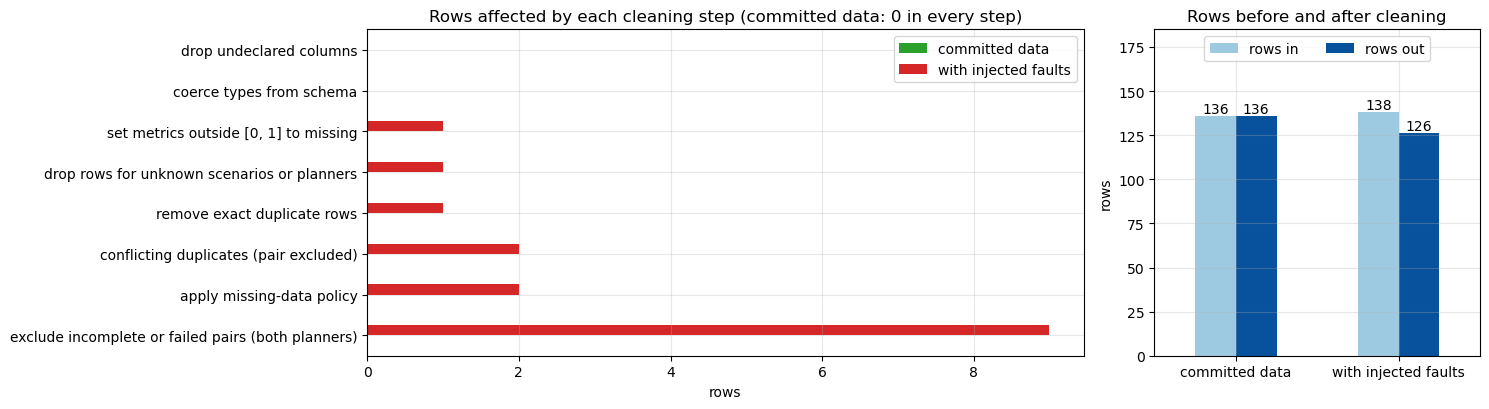

In [12]:
steps = pd.DataFrame({"committed data": [s["rows_affected"] for s in cleaned.steps],
                      "with injected faults": [s["rows_affected"] for s in dirty.steps]},
                     index=[s["step"] for s in cleaned.steps])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), gridspec_kw={"width_ratios": [2.2, 1]})
steps.iloc[::-1].plot.barh(ax=axes[0], color=["#2ca02c", "#d62728"])
axes[0].set(title="Rows affected by each cleaning step (committed data: 0 in every step)", xlabel="rows", ylabel="")
rows = pd.DataFrame({"rows in": [len(sources["outcome_rows"]), len(faulty)],
                     "rows out": [len(cleaned.rows), len(dirty.rows)]},
                    index=["committed data", "with injected faults"])
rows.plot.bar(ax=axes[1], color=["#9ecae1", "#08519c"], rot=0)
for container in axes[1].containers:
    axes[1].bar_label(container)
axes[1].set(title="Rows before and after cleaning", ylabel="rows", ylim=(0, 185))
axes[1].legend(loc="upper center", ncol=2)
fig.tight_layout()
save(fig, "03_cleaning_steps")
plt.show()

## 3. Preprocessing

`preprocess()` turns the clean long table into analysis-ready tables:

- **Matched-pair table**: one row per scenario with IDM and PDM-Closed outcomes side by side
  (`idm_*`, `pdm_*`), plus derived columns: `score_delta` (PDM-Closed - IDM),
  `pair_outcome`, `*_gate_failed` (a nuPlan multiplier metric is 0, so the score is 0) and
  `*_at_fault_collision`.
- **Model-feature table**: join keys plus the pre-simulation features that are available
  now. Only `map_name` is available until the nuPlan databases are mounted; outcomes,
  planner and run IDs are never included.
- **Log-grouped folds**: 5 folds, whole logs per fold, deterministic (seed 0).

In [13]:
paired, features, splits, assignment = preprocess(sources["manifest_rows"], cleaned.rows, schema)
paired_df = pd.DataFrame(paired)
print(f"matched-pair table: {paired_df.shape[0]} rows x {paired_df.shape[1]} columns")
paired_df[["scenario_type", "city", "idm_score", "pdm_score", "score_delta", "pair_outcome",
           "idm_gate_failed", "pdm_gate_failed", "fold"]].head(8)

matched-pair table: 68 rows x 32 columns


,scenario_type,city,idm_score,pdm_score,score_delta,pair_outcome,idm_gate_failed,pdm_gate_failed,fold
0,low_magnitude_speed,las_vegas,0.995437,1.000000,0.004563,pdm_better,False,False,4
1,high_magnitude_speed,las_vegas,1.000000,1.000000,0.000000,tie,False,False,4
2,starting_straight_traffic_light_intersection_traversal,las_vegas,0.984959,0.995409,0.010450,pdm_better,False,False,4
3,stationary_in_traffic,las_vegas,1.000000,1.000000,0.000000,tie,False,False,1
4,stopping_with_lead,las_vegas,1.000000,1.000000,0.000000,tie,False,False,1
5,starting_right_turn,las_vegas,0.968954,1.000000,0.031046,pdm_better,False,False,0
6,traversing_pickup_dropoff,las_vegas,0.797747,0.793678,-0.004070,idm_better,False,False,0
7,traversing_pickup_dropoff,las_vegas,0.890899,0.896581,0.005682,pdm_better,False,False,0


In [14]:
print("long format :", len(cleaned.rows), "rows (scenario x planner)")
print("wide format :", len(paired_df), "rows (scenario), columns per planner:",
      sum(c.startswith("idm_") for c in paired_df.columns))
paired_df["pair_outcome"].value_counts()

long format : 136 rows (scenario x planner)
wide format : 68 rows (scenario), columns per planner: 11


pair_outcome
pdm_better    33
tie           30
idm_better     5
Name: count, dtype: int64

**The matched-pair view.** Each point is one scenario with its IDM score on the x-axis and
its PDM-Closed score on the y-axis; points above the diagonal are scenarios where
PDM-Closed scored higher. The right panel is the derived `score_delta` column.

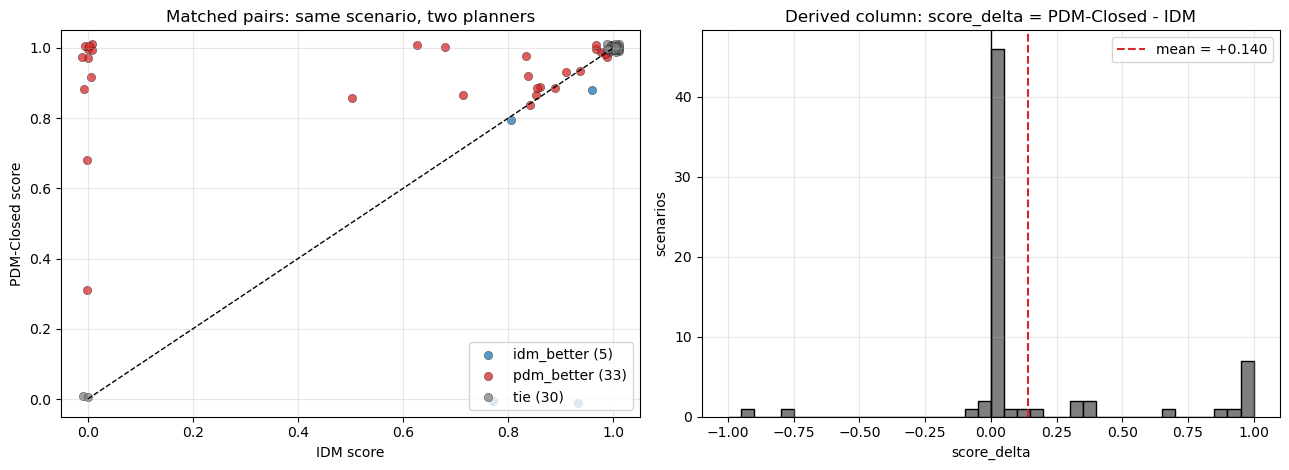

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
jitter = np.random.default_rng(1).uniform(-0.012, 0.012, size=(2, len(paired_df)))
for outcome, group in paired_df.groupby("pair_outcome"):
    idx = group.index
    axes[0].scatter(group.idm_score + jitter[0, idx], group.pdm_score + jitter[1, idx], label=f"{outcome} ({len(group)})",
                    color=OUTCOME_COLORS[outcome], alpha=0.75, edgecolor="k", linewidth=0.3)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(title="Matched pairs: same scenario, two planners", xlabel="IDM score", ylabel="PDM-Closed score",
            xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
axes[0].legend(loc="lower right")
axes[1].hist(paired_df.score_delta, bins=np.linspace(-1, 1, 41), color="#7f7f7f", edgecolor="k")
axes[1].axvline(0, color="k", lw=1)
axes[1].axvline(paired_df.score_delta.mean(), color="#d62728", lw=1.5, ls="--",
                label=f"mean = {paired_df.score_delta.mean():+.3f}")
axes[1].set(title="Derived column: score_delta = PDM-Closed - IDM", xlabel="score_delta", ylabel="scenarios")
axes[1].legend()
fig.tight_layout()
save(fig, "04_matched_pairs")
plt.show()

In [16]:
print("model-feature table columns:", list(features[0]))
pd.DataFrame(features).head(3)

model-feature table columns: ['scenario_id', 'log_name', 'scenario_token', 'map_name']


,scenario_id,log_name,scenario_token,map_name
0,2021.05.12.22.00.38_veh-35_01008_01518:54f95d530b535ebf,2021.05.12.22.00.38_veh-35_01008_01518,54f95d530b535ebf,us-nv-las-vegas-strip
1,2021.05.12.22.00.38_veh-35_01008_01518:bc45cfff686751c4,2021.05.12.22.00.38_veh-35_01008_01518,bc45cfff686751c4,us-nv-las-vegas-strip
2,2021.05.12.22.00.38_veh-35_01008_01518:f1e76c9854a15b03,2021.05.12.22.00.38_veh-35_01008_01518,f1e76c9854a15b03,us-nv-las-vegas-strip


In [17]:
folds = paired_df.groupby("fold").agg(logs=("log_name", "nunique"), scenarios=("scenario_id", "size"),
                                      categories=("scenario_type", "nunique"), maps=("map_name", "nunique"),
                                      mean_score_delta=("score_delta", "mean"))
folds

,logs,scenarios,categories,maps,mean_score_delta
fold,,,,,
0,8,14,7,2,0.095331
1,8,14,9,3,0.308636
2,8,14,8,3,0.172254
3,7,13,9,3,0.130696
4,7,13,11,1,-0.017176


**Log-grouped folds.** Whole logs go to one fold, so fold sizes are balanced by scenario
count but cities and categories are not perfectly spread (for example, Singapore is a
single log). The heatmap shows how each category is distributed across folds.

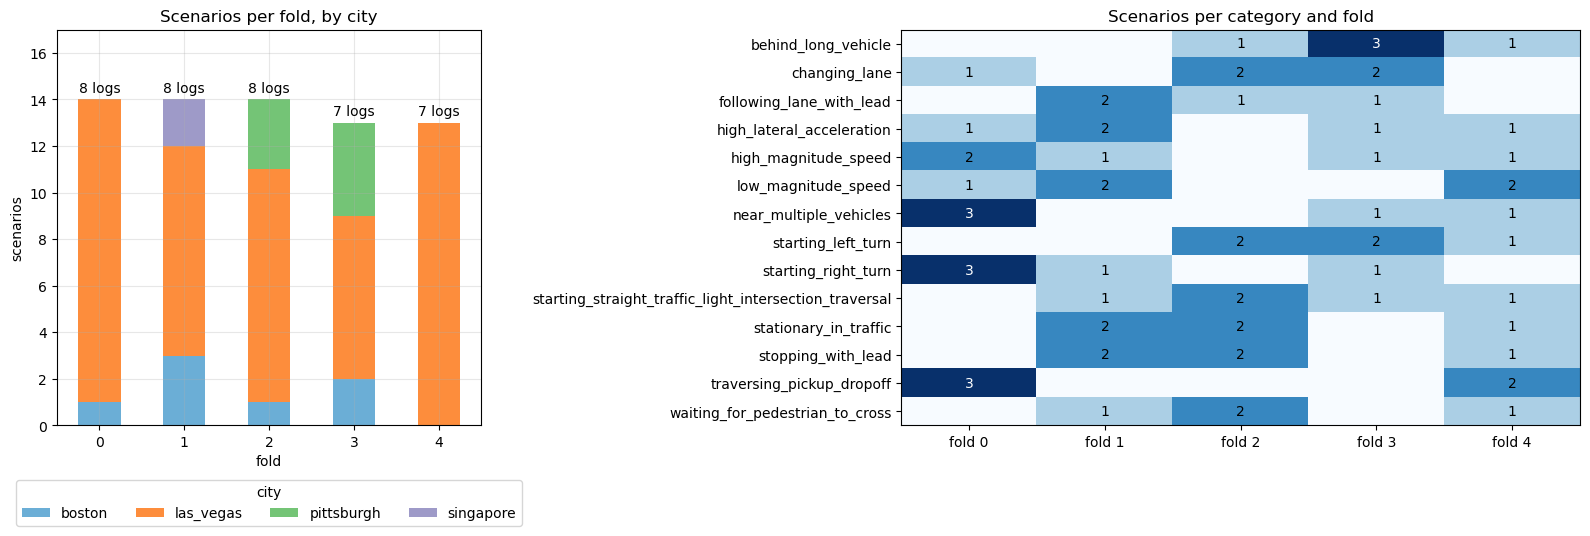

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 1.6]})
by_city = paired_df.groupby(["fold", "city"]).size().unstack(fill_value=0)
by_city.plot.bar(stacked=True, ax=axes[0], rot=0, color=["#6baed6", "#fd8d3c", "#74c476", "#9e9ac8"])
for fold, logs in folds["logs"].items():
    axes[0].text(fold, folds.loc[fold, "scenarios"] + 0.3, f"{logs} logs", ha="center")
axes[0].set(title="Scenarios per fold, by city", xlabel="fold", ylabel="scenarios", ylim=(0, 17))
axes[0].legend(title="city", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
crosstab = pd.crosstab(paired_df.scenario_type, paired_df.fold)
axes[1].imshow(crosstab.to_numpy(), cmap="Blues", aspect="auto", vmin=0, vmax=crosstab.to_numpy().max())
axes[1].set_xticks(range(crosstab.shape[1]), [f"fold {k}" for k in crosstab.columns])
axes[1].set_yticks(range(crosstab.shape[0]), crosstab.index)
for (i, j), value in np.ndenumerate(crosstab.to_numpy()):
    if value:
        axes[1].text(j, i, str(value), ha="center", va="center", color="white" if value >= 3 else "black")
axes[1].grid(False)
axes[1].set_title("Scenarios per category and fold")
fig.tight_layout()
save(fig, "05_folds")
plt.show()

## 4. Data quality assessment

`assess_quality()` checks the processed data along standard quality dimensions, and the
subset validator re-checks the committed inputs (manifest, pairing, leakage, provenance):

In [19]:
report = assess_quality(schema, sources, cleaned, paired, features, assignment)
validator = validate(DEFAULT_SCHEMA)
report["subset_validator_failures"] = [c["check"] for c in validator.failed]
print("quality report:", "PASS" if report["passed"] and not validator.failed else "FAIL")
pd.DataFrame(report["checks"])

quality report: PASS


,check,status,detail
0,cleaning: no fatal errors,PASS,ok
1,cleaning: excluded scenarios,PASS,0 excluded
2,completeness: no nulls in the paired table,PASS,32 columns x 68 rows
3,completeness: every map has a city,PASS,via city_by_map_name
4,uniqueness: one row per scenario and token,PASS,68 unique scenarios
5,"validity: every score and metric in [0, 1]",PASS,9 metrics x 2 planners
6,consistency: score = multipliers x weighted metrics,PASS,max abs error 1.1e-16
7,consistency: outcomes come from the frozen manifest,PASS,9162d8ae9d81a106
8,consistency: planner means equal official aggregates,PASS,"idm 0.7601, pdm-closed 0.9004"
9,coverage: subset size after cleaning,PASS,"{""scenarios"": 68, ""scenario_types"": 14, ""logs"": 38, ""maps"": 4}"


In [20]:
summary = pd.DataFrame(validator.checks)
print(f"subset validator: {len(summary)} checks, {len(validator.failed)} required failures")
summary.groupby("status").size().rename("checks").to_frame()

subset validator: 34 checks, 0 required failures


,checks
status,
INFO,7
PASS,23
SKIP,2
WARN,2


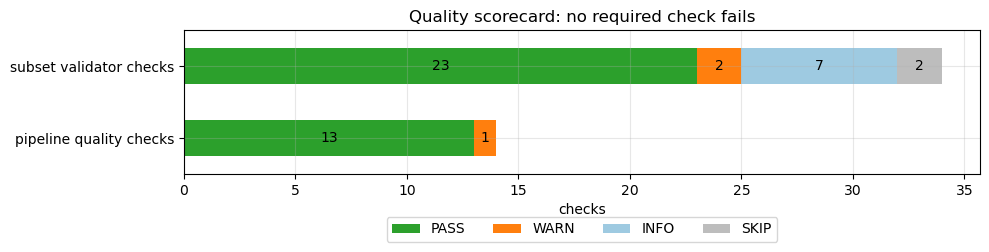

In [21]:
scorecard = pd.DataFrame({
    "pipeline quality checks": pd.Series([c["status"] for c in report["checks"]]).value_counts(),
    "subset validator checks": summary["status"].value_counts(),
}).T.fillna(0).astype(int)
order = [s for s in STATUS_COLORS if s in scorecard.columns]
fig, ax = plt.subplots(figsize=(10, 2.8))
scorecard[order].plot.barh(stacked=True, ax=ax, color=[STATUS_COLORS[s] for s in order])
for container in ax.containers:
    ax.bar_label(container, label_type="center", labels=[str(int(v)) if v else "" for v in container.datavalues])
ax.set(title="Quality scorecard: no required check fails", xlabel="checks", ylabel="")
ax.legend(ncol=len(order), loc="upper center", bbox_to_anchor=(0.5, -0.25))
fig.tight_layout()
save(fig, "06_quality_scorecard")
plt.show()

**Consistency and validity.** Left: the stored score is rebuilt from its eight component
metrics with nuPlan's formula (multipliers x weighted average); every point lies on the
diagonal. Right: every metric value for both planners lies inside its valid range [0, 1].

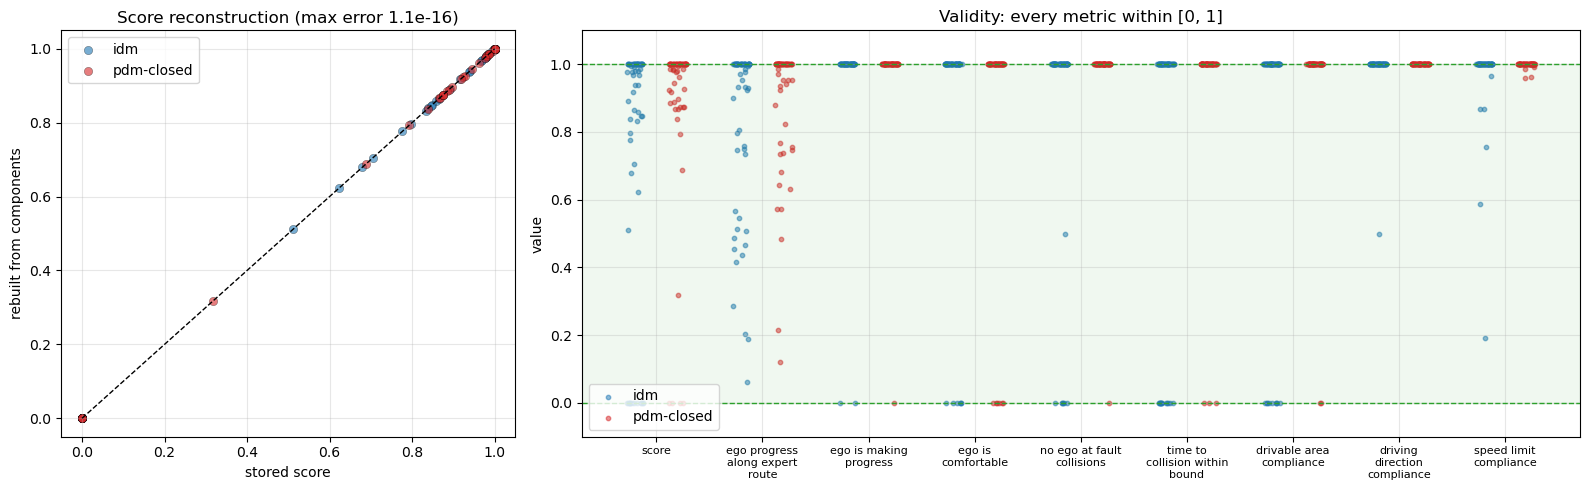

In [22]:
long_clean = pd.DataFrame(cleaned.rows)
long_clean["reconstructed"] = [reconstruct_score(r) for r in cleaned.rows]
max_error = (long_clean.reconstructed - long_clean.score).abs().max()
metrics = outcome_metrics(schema)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2.2]})
for planner, group in long_clean.groupby("planner"):
    axes[0].scatter(group.score, group.reconstructed, color=COLORS[planner], alpha=0.6, label=planner,
                    edgecolor="k", linewidth=0.3)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(title=f"Score reconstruction (max error {max_error:.1e})", xlabel="stored score",
            ylabel="rebuilt from components")
axes[0].legend()
rng = np.random.default_rng(2)
for i, metric in enumerate(metrics):
    for offset, planner in ((-0.2, "idm"), (0.2, "pdm-closed")):
        values = long_clean.loc[long_clean.planner == planner, metric]
        axes[1].scatter(i + offset + rng.uniform(-0.08, 0.08, len(values)), values, s=10, alpha=0.5,
                        color=COLORS[planner], label=planner if i == 0 else None)
axes[1].axhspan(0, 1, color="#2ca02c", alpha=0.07)
axes[1].axhline(0, color="#2ca02c", lw=1, ls="--")
axes[1].axhline(1, color="#2ca02c", lw=1, ls="--")
axes[1].set_xticks(range(len(metrics)), [textwrap.fill(m.replace("_", " "), 16) for m in metrics], fontsize=8)
axes[1].set(title="Validity: every metric within [0, 1]", ylabel="value", ylim=(-0.1, 1.1))
axes[1].legend(loc="lower left")
fig.tight_layout()
save(fig, "07_consistency_validity")
plt.show()

**Field availability.** Completeness of what exists is 100%, but most pre-simulation
features still need extraction. This is the main open data gap:

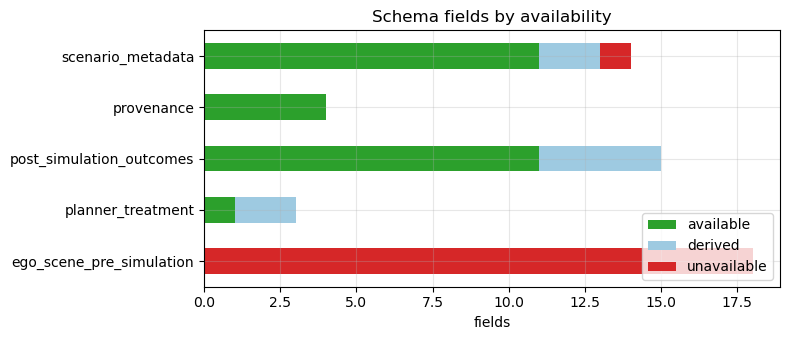

status,available,derived,unavailable
group,,,
ego_scene_pre_simulation,0,0,18
planner_treatment,1,2,0
post_simulation_outcomes,11,4,0
provenance,4,0,0
scenario_metadata,11,2,1


In [23]:
availability = fields.groupby(["group", "status"]).size().unstack(fill_value=0)
availability = availability.reindex(columns=["available", "derived", "unavailable"], fill_value=0)
fig, ax = plt.subplots(figsize=(8, 3.5))
availability.plot.barh(stacked=True, ax=ax, color=["#2ca02c", "#9ecae1", "#d62728"])
ax.set(title="Schema fields by availability", xlabel="fields", ylabel="")
ax.legend(loc="lower right")
fig.tight_layout()
save(fig, "08_field_availability")
plt.show()
availability

In [24]:
pd.Series(report["metrics"]["rows"]).rename("count").to_frame()

,count
outcome_rows_in,136
outcome_rows_clean,136
manifest_scenarios,68
pairs,68
excluded_scenarios,0


Write the processed tables and reports to `artifacts/processed/mini_68/` (ignored by Git):

In [25]:
output_dir = ROOT / "artifacts" / "processed" / "mini_68"
written = write_outputs(output_dir, paired, features, splits, cleaned, report, overwrite=True)
for name in written:
    print(f"{(output_dir / name).stat().st_size:>8,} bytes  {name}")

  26,391 bytes  paired_outcomes.csv
   9,180 bytes  model_features.csv
   6,691 bytes  splits.csv
   1,022 bytes  cleaning_log.json
   3,924 bytes  quality_report.json
   3,304 bytes  quality_report.md
  29,570 bytes  paired_outcomes.parquet


## Summary

| Stage | Status |
| --- | --- |
| Extraction | Scenario catalog, selection, simulation and outcome extraction done; outcomes committed (136 rows). Pre-simulation feature extraction waits for the nuPlan databases. |
| Cleaning | Schema-driven rules implemented and tested; committed data is clean (0 exclusions); fault injection shows every rule working. |
| Preprocessing | 68-row matched-pair table, model-feature table and log-grouped folds produced deterministically. |
| Quality assessment | All quality checks and the subset validator pass; the remaining gap is the 15 unavailable pre-simulation fields. |

Outcome-level EDA: [`mini_68_outcomes_eda.ipynb`](mini_68_outcomes_eda.ipynb).